# 💳 Credit-Card Fraud Detection — End-to-End ML & Deep-Learning Pipeline

**Author:** *Kali*  
**Role:** Data Science / ML Engineering Portfolio Project  
**Stack:** `pandas` · `numpy` · `scikit-learn` · `lightgbm` · `imbalanced-learn` · `optuna` · `pytorch` · `shap` · `plotly` · `seaborn`

---

## 🎯 Business Problem

Fraudulent card transactions represent a tiny fraction of all payment traffic
(≈ **0.172 %** in the public Kaggle dataset), yet they cause disproportionately
large financial and reputational damage. The modelling challenge is therefore
**not classification accuracy** — a model that predicts *"not fraud"* for every
transaction would score **99.83 %** and be completely useless. The real
objective is to **maximise recall on the minority (fraud) class while keeping
false positives low enough for the operations team to review**.

## 🗺️ Notebook Roadmap

| Phase | Focus | Key Techniques |
|-------|-------|----------------|
| **1** | Advanced EDA & Feature Engineering | `RobustScaler`, correlation heatmaps, time-based fraud patterns |
| **2** | Imbalance Handling & CV Setup | `StratifiedKFold`, `SMOTE`, class weighting |
| **3** | ML Track — Gradient Boosting | `LightGBM` + `Optuna` Bayesian tuning |
| **4** | DL Track — Deep Neural Net | PyTorch FFN with BatchNorm, Dropout, LR scheduling, early stopping |
| **5** | Evaluation & Explainable AI | PR-AUC, F1, FNR, confusion matrix, **SHAP** attributions |

## 📦 Dataset

We use the [**Kaggle Credit Card Fraud Detection**](https://www.kaggle.com/mlg-ulb/creditcardfraud) dataset
(284 807 transactions, 492 fraud). Features `V1…V28` are the output of an
upstream PCA (real feature names are anonymised for privacy). `Time` and
`Amount` are raw. The target `Class` is `1` for fraud, `0` otherwise.

> **How to get the data:** Download `creditcard.csv` from Kaggle and drop it
> in the working directory, or use the Kaggle CLI:
>
> ```bash
> pip install kaggle
> kaggle datasets download -d mlg-ulb/creditcardfraud
> unzip creditcardfraud.zip
> ```

In [2]:
# --- Colab bootstrap: pinned deps + Kaggle data via new token format ---
!pip install -q lightgbm==4.5.0 optuna==3.6.1 shap==0.46.0 imbalanced-learn==0.12.4 plotly==5.24.1

import os, getpass, pathlib

if not pathlib.Path("creditcard.csv").exists():
    # Paste your NEW token here when prompted (input is hidden)
    token = getpass.getpass("Paste your Kaggle API token (KGAT_...): ").strip()
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    token_path = os.path.expanduser("~/.kaggle/access_token")
    with open(token_path, "w") as f:
        f.write(token)
    os.chmod(token_path, 0o600)

    !kaggle datasets download -d mlg-ulb/creditcardfraud
    !unzip -o creditcardfraud.zip

!ls -lh creditcard.csv

Paste your Kaggle API token (KGAT_...): ··········
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 203MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
-rw-r--r-- 1 root root 144M Sep 20  2019 creditcard.csv


## 0 · Environment Setup

We pin the random seeds so every stochastic component — train/test split,
SMOTE sampling, Optuna trials, PyTorch weight init — produces identical
results across runs. Reproducibility is a hard requirement for any model that
will ever face a model-risk review.

In [3]:
# ---- Core scientific stack ----
import os
import warnings
import random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd

# ---- Visualisation ----
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ---- Modelling ----
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score,
)

from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import shap

# ---- Housekeeping ----
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")

PyTorch device: cuda


---

# 📊 Phase 1 — Advanced EDA & Feature Engineering

Before touching any model we need to *understand the data generating process*.
For a fraud dataset the four questions we always ask are:

1. **How imbalanced is the target?** Determines the loss/metric strategy.
2. **How do fraud amounts differ from legitimate ones?** Determines whether
   `Amount` is signal on its own.
3. **Are frauds concentrated in specific time windows?** Points at diurnal
   attack patterns.
4. **Which anonymised PCA components separate the classes?** Guides model
   selection between linear and non-linear learners.

In [4]:
DATA_PATH = Path("creditcard.csv")  # adjust if you kept it elsewhere

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Basic sanity: dtypes, null values, target balance
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "n_unique": df.nunique(),
})
display(summary.T)

class_counts = df["Class"].value_counts()
fraud_rate = class_counts[1] / class_counts.sum()
print(f"Legitimate: {class_counts[0]:>7,}")
print(f"Fraud:      {class_counts[1]:>7,}")
print(f"Fraud rate: {fraud_rate:.4%}")

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
n_missing,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
n_unique,124592,275663,275663,275663,275663,275663,275663,275663,275663,275663,...,275663,275663,275663,275663,275663,275663,275663,275663,32767,2


Legitimate: 284,315
Fraud:          492
Fraud rate: 0.1727%


### 1.1 · Class-Imbalance Visualisation

A log-scaled bar chart is the honest way to show a **~578:1 imbalance**. A
linear scale would make the fraud bar invisible.

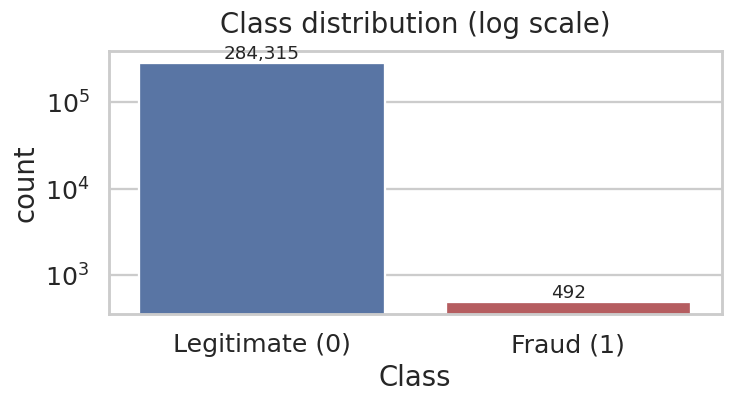

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="Class", ax=ax,
              palette=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_title("Class distribution (log scale)", pad=12)
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=12)
plt.tight_layout()
plt.show()

### 1.2 · Amount & Time Distributions

`Amount` is right-skewed and contains extreme outliers — the median is a few
tens of euros but the maximum is > €25 000. Any distance-based model
(neural network, k-NN, logistic regression) will be dominated by these
outliers unless we scale robustly.

`Time` is *seconds since the first transaction* over a 48-hour window. Fraud
tends to cluster in the early hours of the morning, so raw seconds carry real
signal — we'll keep it but scale it too.

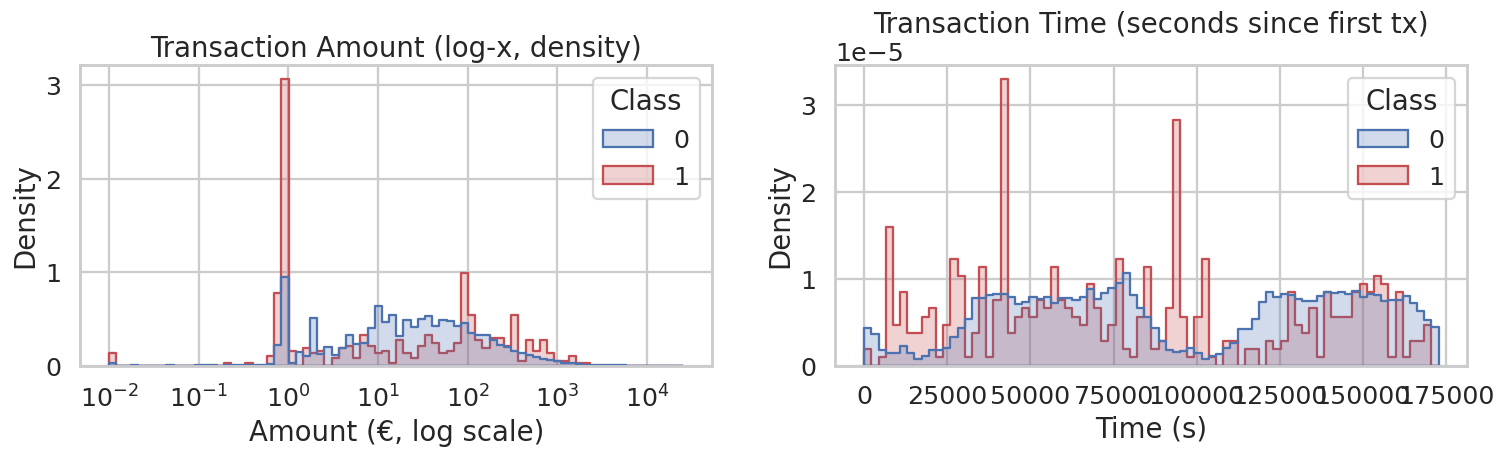

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(data=df, x="Amount", hue="Class", bins=80,
             log_scale=(True, False), ax=axes[0],
             palette=["#4C72B0", "#C44E52"], element="step",
             common_norm=False, stat="density")
axes[0].set_title("Transaction Amount (log-x, density)")
axes[0].set_xlabel("Amount (€, log scale)")

sns.histplot(data=df, x="Time", hue="Class", bins=80, ax=axes[1],
             palette=["#4C72B0", "#C44E52"], element="step",
             common_norm=False, stat="density")
axes[1].set_title("Transaction Time (seconds since first tx)")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### 1.3 · Correlation Heatmap of PCA Components

The `V1…V28` features were produced by PCA on Kaggle's side, so they are
**orthogonal by construction** — the heatmap should be almost diagonal. The
interesting bit is the *last row/column*: how strongly does each PCA
component correlate with `Class`? Strong absolute correlations flag the
components a linear model would lean on most.

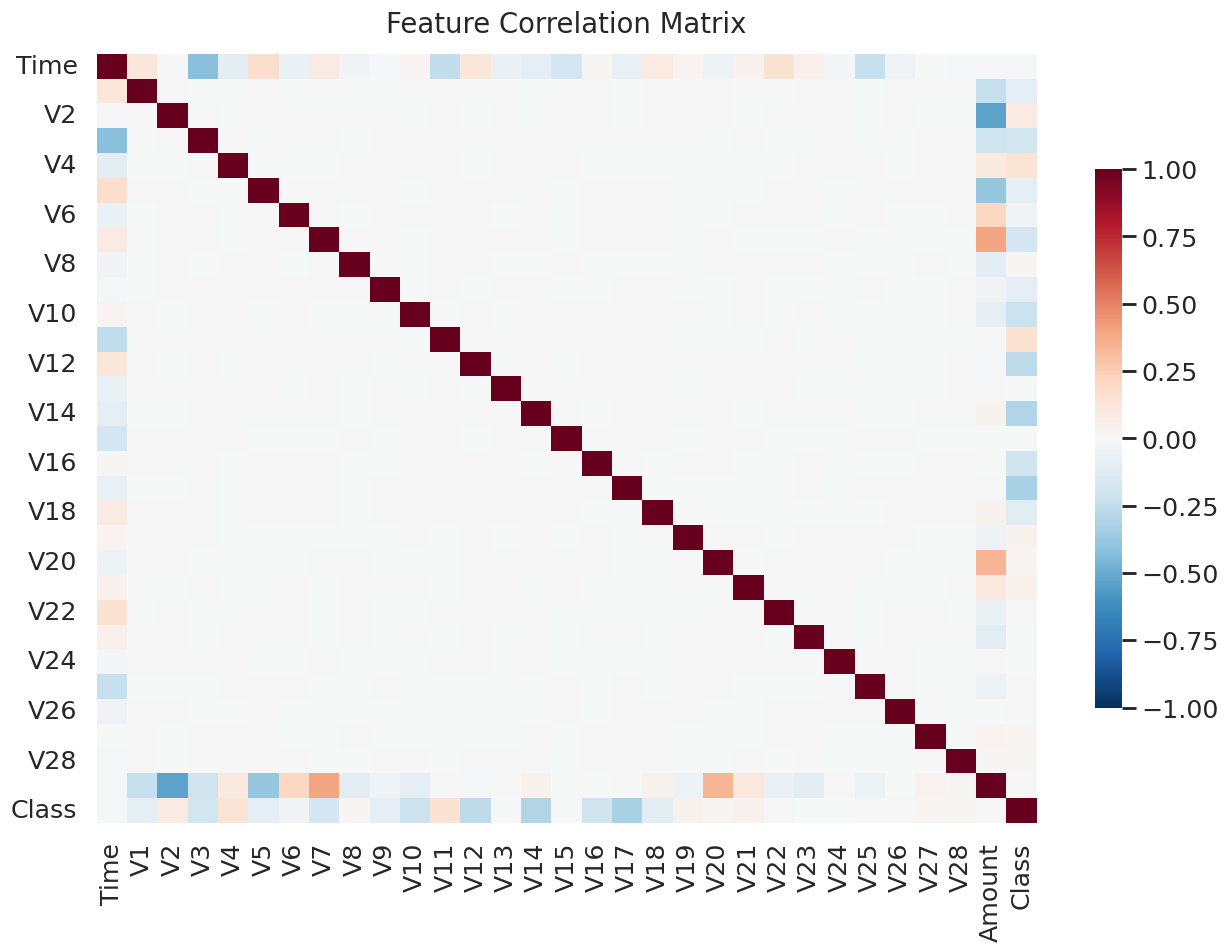

Top 10 features by |corr(Class)|
V17    0.326
V14    0.303
V12    0.261
V10    0.217
V16    0.197
V3     0.193
V7     0.187
V11    0.155
V4     0.133
V18    0.111
Name: Class, dtype: float64


In [8]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Feature Correlation Matrix", pad=14)
plt.tight_layout()
plt.show()

# The signal features — components most correlated (positively or negatively) with fraud
top_signal = (corr["Class"]
              .drop("Class")
              .abs()
              .sort_values(ascending=False)
              .head(10))
print("Top 10 features by |corr(Class)|")
print(top_signal.round(3))

### 1.4 · Time-Series Fraud Rate

We bucket transactions into 30-minute bins and plot the **fraud rate over
time** (an interactive Plotly chart so you can hover). Notice the two nightly
spikes — these correspond to periods of low legitimate volume, which
mechanically boosts the ratio. This is a *seasonality* insight that would
justify time-of-day features in a production pipeline.

In [9]:
BIN_SECONDS = 30 * 60  # 30-minute buckets
df["time_bin"] = (df["Time"] // BIN_SECONDS).astype(int)

fraud_ts = (df.groupby("time_bin")["Class"]
            .agg(["sum", "count"])
            .reset_index()
            .rename(columns={"sum": "n_fraud", "count": "n_tx"}))
fraud_ts["fraud_rate"] = fraud_ts["n_fraud"] / fraud_ts["n_tx"]
fraud_ts["hour"] = fraud_ts["time_bin"] * BIN_SECONDS / 3600

fig = px.line(fraud_ts, x="hour", y="fraud_rate",
              title="Fraud rate over the 48-hour observation window",
              labels={"hour": "Hours since first transaction",
                      "fraud_rate": "Fraud rate"})
fig.update_traces(line=dict(width=2.5, color="#C44E52"))
fig.update_layout(template="plotly_white", height=420)
fig.show()

df.drop(columns=["time_bin"], inplace=True)

### 1.5 · Robust Scaling of `Amount` and `Time`

`V1…V28` are already standardised (they come from PCA). Only `Amount` and
`Time` are on their raw scale. We use **`RobustScaler`** — which centres by
the median and scales by the IQR — instead of `StandardScaler`:

$$
x'_i \;=\; \dfrac{x_i - \operatorname{median}(x)}{Q_{75}(x) - Q_{25}(x)}
$$

Why it matters:

- Neural networks and gradient-based ML models converge much faster and more
  stably when inputs share a common scale.
- Fraud amounts are *the outliers we care about*. `StandardScaler`
  uses the mean and variance — both of which are dragged by those same
  outliers — so genuine fraud signal gets **muted**. `RobustScaler`
  ignores the tails when computing the scaling constants but keeps the
  original values, so the extreme fraud amounts remain visible to the model.

In [10]:
scaler = RobustScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"]   = scaler.fit_transform(df[["Time"]])

# Drop the raw versions and reorder so target sits at the end
df = df.drop(columns=["Amount", "Time"])
scaled_cols = ["Time_scaled", "Amount_scaled"]
feature_cols = scaled_cols + [c for c in df.columns if c.startswith("V")]
df = df[feature_cols + ["Class"]]

df.head()

,Time_scaled,Amount_scaled,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-0.994983,1.783274,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.994983,-0.269825,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,-0.994972,4.983721,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,-0.994972,1.418291,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.994960,0.670579,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


---

# ⚖️ Phase 2 — Imbalance Handling & Cross-Validation Setup

## 2.1 · Why Stratified K-Fold?

With only 492 positives in 284 807 rows, a naïve random split can easily
create folds with radically different fraud rates (or zero positives in the
test set). `StratifiedKFold` preserves the class ratio in every fold, giving
us honest, comparable performance estimates.

## 2.2 · Why SMOTE — and where NOT to apply it

**SMOTE (Synthetic Minority Over-sampling TEchnique)** creates synthetic
minority examples by interpolating between real minority points and their
nearest neighbours:

$$
x_{\text{new}} = x_i + \lambda\,(x_{\text{nn}} - x_i),\qquad \lambda \sim U(0,1)
$$

This is preferable to naïve duplication because it enlarges the *decision
region* around the minority class rather than piling weight on identical
points.

> **Critical rule:** SMOTE must be applied to the **training fold only**. If
> we resample before splitting, synthetic minority points leak into the test
> set and inflate every metric. Below we build a helper that resamples inside
> each CV iteration.

In [11]:
X = df.drop(columns=["Class"]).values.astype(np.float32)
y = df["Class"].values.astype(np.int64)

# Hold-out set — never touched until the very end
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Train: {X_train.shape},   fraud rate = {y_train.mean():.4%}")
print(f"Test : {X_test.shape },   fraud rate = {y_test.mean():.4%}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Train: (227845, 30),   fraud rate = 0.1729%
Test : (56962, 30),   fraud rate = 0.1720%


In [12]:
def resample_smote(X_fold: np.ndarray,
                   y_fold: np.ndarray,
                   ratio: float = 0.1,
                   seed: int = SEED) -> tuple[np.ndarray, np.ndarray]:
    """Apply SMOTE to a single training fold.

    Parameters
    ----------
    X_fold, y_fold : arrays for one CV training partition.
    ratio          : desired positive:negative ratio after resampling.
                     0.1 → minority class becomes 10 % of the majority.
    """
    smote = SMOTE(sampling_strategy=ratio, random_state=seed, n_jobs=-1)
    return smote.fit_resample(X_fold, y_fold)


X_demo, y_demo = resample_smote(X_train, y_train, ratio=0.1)
print(f"Before SMOTE — positives: {y_train.sum():>6,} / {len(y_train):,}"
      f"  ({y_train.mean():.3%})")
print(f"After  SMOTE — positives: {y_demo.sum():>6,} / {len(y_demo):,}"
      f"  ({y_demo.mean():.3%})")

Before SMOTE — positives:    394 / 227,845  (0.173%)
After  SMOTE — positives: 22,745 / 250,196  (9.091%)


---

# 🌳 Phase 3 — Machine-Learning Track: LightGBM + Optuna

Gradient-boosted decision trees dominate tabular fraud detection because:

- They handle *non-linear* interactions between PCA components natively.
- They are **scale-invariant** (unaffected by our previous scaling — which is
  a nice sanity check).
- They expose native support for `scale_pos_weight`, giving us a *second*
  imbalance lever on top of SMOTE.

For hyperparameter search we use **Optuna** — a Bayesian TPE (Tree-structured
Parzen Estimator) sampler that outperforms grid/random search in both wall
clock and final metric, especially in the 5-to-20 hyperparameter regime.

In [13]:
def lgb_objective(trial: optuna.Trial) -> float:
    """Optuna objective — maximise mean PR-AUC across CV folds."""
    params = {
        "objective": "binary",
        "metric": "average_precision",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "n_estimators": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        # Second imbalance lever — inversely proportional to fraud rate
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 600.0),
        "random_state": SEED,
        "n_jobs": -1,
    }

    fold_scores = []
    for fold_idx, (tr, va) in enumerate(cv.split(X_train, y_train)):
        X_tr, y_tr = X_train[tr], y_train[tr]
        X_va, y_va = X_train[va], y_train[va]

        X_tr_res, y_tr_res = resample_smote(X_tr, y_tr, ratio=0.1)

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr_res, y_tr_res,
            eval_set=[(X_va, y_va)],
            eval_metric="average_precision",
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        preds = model.predict_proba(X_va)[:, 1]
        fold_scores.append(average_precision_score(y_va, preds))

    return float(np.mean(fold_scores))


study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

print(f"Best CV PR-AUC: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]

Best CV PR-AUC: 0.8550
Best params:
  learning_rate: 0.14160964878152063
  num_leaves: 252
  max_depth: 10
  min_child_samples: 78
  subsample: 0.6801274180281731
  colsample_bytree: 0.619720671481651
  reg_alpha: 0.010276990958701415
  reg_lambda: 0.0623529243768886
  scale_pos_weight: 360.54445768608014


In [14]:
# Retrain on the full training set with the best hyperparameters
best_params = {
    "objective": "binary",
    "metric": "average_precision",
    "verbosity": -1,
    "n_estimators": 2000,
    "random_state": SEED,
    "n_jobs": -1,
    **study.best_params,
}

X_train_res, y_train_res = resample_smote(X_train, y_train, ratio=0.1)

lgb_model = lgb.LGBMClassifier(**best_params)
lgb_model.fit(X_train_res, y_train_res,
              eval_set=[(X_test, y_test)],
              eval_metric="average_precision",
              callbacks=[lgb.early_stopping(50, verbose=False)])

y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = (y_prob_lgb >= 0.5).astype(int)

print(classification_report(y_test, y_pred_lgb,
                            target_names=["Legit", "Fraud"], digits=4))
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_lgb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lgb):.4f}")

              precision    recall  f1-score   support

       Legit     0.9998    0.9995    0.9996     56864
       Fraud     0.7568    0.8571    0.8038        98

    accuracy                         0.9993     56962
   macro avg     0.8783    0.9283    0.9017     56962
weighted avg     0.9993    0.9993    0.9993     56962

PR-AUC   : 0.8758
ROC-AUC  : 0.9780


### 3.1 · Precision–Recall Curve

For heavily imbalanced problems the ROC curve is deceptively optimistic — the
huge negative class means even a bad classifier has a high true-negative
rate. The **PR curve** ignores true negatives entirely and shows the
precision/recall trade-off directly. **Area under PR (Average Precision)** is
the honest headline metric.

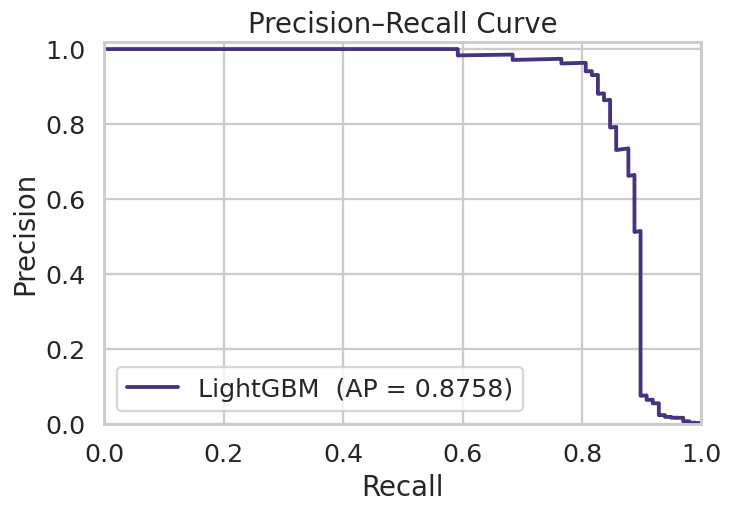

In [15]:
def plot_pr_curve(y_true, y_prob, label, ax=None):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    ax.plot(recall, precision, lw=2.5, label=f"{label}  (AP = {ap:.4f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall Curve")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(loc="lower left")
    return ax


plot_pr_curve(y_test, y_prob_lgb, "LightGBM")
plt.tight_layout(); plt.show()

---

# 🧠 Phase 4 — Deep-Learning Track: PyTorch Feed-Forward Network

While tree ensembles are hard to beat on tabular data, a well-regularised
dense network gives us a **second, independent hypothesis class** — useful
both as a benchmark and as a candidate for a future ensemble/stacking layer.

## Architecture choices

- **BatchNorm** after each linear layer: stabilises training by re-centring
  activations, which matters after SMOTE has inflated the input distribution.
- **Dropout (0.3)**: prevents co-adaptation of neurons; important because
  our effective sample size for the *fraud* class is still tiny.
- **`pos_weight` in `BCEWithLogitsLoss`** instead of SMOTE: for the DL model
  we prefer weighting because it keeps every input *authentic* and lets the
  optimiser see the true joint distribution — just with a heavier gradient
  contribution from the fraud class.
- **ReduceLROnPlateau + Early Stopping**: standard defensive combo — halve
  the LR when validation loss plateaus, stop entirely when it hasn't
  improved for `patience` epochs.

In [16]:
class FraudNet(nn.Module):
    """Compact 4-layer MLP for tabular fraud detection."""

    def __init__(self, in_features: int, hidden: tuple[int, ...] = (128, 64, 32),
                 dropout: float = 0.3):
        super().__init__()
        layers: list[nn.Module] = []
        prev = in_features
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))  # raw logit
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

In [17]:
# ---- Torch tensors / loaders ----
X_tr_t, X_va_t, y_tr_t, y_va_t = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=SEED
)

def to_loader(X_arr, y_arr, batch_size=1024, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X_arr).float(),
                       torch.from_numpy(y_arr).float())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=torch.cuda.is_available())

train_loader = to_loader(X_tr_t, y_tr_t, batch_size=2048, shuffle=True)
val_loader   = to_loader(X_va_t, y_va_t, batch_size=4096)
test_loader  = to_loader(X_test, y_test, batch_size=4096)

# ---- Loss with class weighting ----
pos_weight = torch.tensor([(y_tr_t == 0).sum() / max((y_tr_t == 1).sum(), 1)],
                          dtype=torch.float32, device=DEVICE)
print(f"pos_weight = {pos_weight.item():.1f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

pos_weight = 577.1


In [18]:
@dataclass
class TrainConfig:
    epochs: int = 60
    lr: float = 1e-3
    weight_decay: float = 1e-5
    patience: int = 8            # early-stopping patience
    scheduler_patience: int = 3  # LR-scheduler patience


def train_fraudnet(model: nn.Module, cfg: TrainConfig) -> dict:
    """Training loop with early stopping and LR scheduling."""
    model.to(DEVICE)
    optim_ = torch.optim.AdamW(model.parameters(), lr=cfg.lr,
                               weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim_, mode="min", factor=0.5, patience=cfg.scheduler_patience
    )

    history = {"train_loss": [], "val_loss": [], "val_ap": []}
    best_val, best_state, epochs_no_improve = float("inf"), None, 0

    for epoch in range(1, cfg.epochs + 1):
        # ---- train ----
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optim_.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optim_.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        # ---- validation ----
        model.eval()
        val_running, probs, targs = 0.0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                val_running += criterion(logits, yb).item() * xb.size(0)
                probs.append(torch.sigmoid(logits).cpu().numpy())
                targs.append(yb.cpu().numpy())
        val_loss = val_running / len(val_loader.dataset)
        val_ap = average_precision_score(np.concatenate(targs),
                                         np.concatenate(probs))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_ap"].append(val_ap)
        scheduler.step(val_loss)

        improved = val_loss < best_val - 1e-5
        if improved:
            best_val, epochs_no_improve = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch:>2}  train={train_loss:.4f}  "
              f"val={val_loss:.4f}  val_AP={val_ap:.4f}"
              f"  lr={optim_.param_groups[0]['lr']:.2e}"
              f"  {'✓' if improved else ''}")

        if epochs_no_improve >= cfg.patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


net = FraudNet(in_features=X_train.shape[1])
history = train_fraudnet(net, TrainConfig())

Epoch  1  train=0.7725  val=0.5805  val_AP=0.6326  lr=1.00e-03  ✓
Epoch  2  train=0.5013  val=0.4728  val_AP=0.6524  lr=1.00e-03  ✓
Epoch  3  train=0.3949  val=0.4202  val_AP=0.6406  lr=1.00e-03  ✓
Epoch  4  train=0.3384  val=0.4142  val_AP=0.6004  lr=1.00e-03  ✓
Epoch  5  train=0.2888  val=0.3800  val_AP=0.6607  lr=1.00e-03  ✓
Epoch  6  train=0.2657  val=0.3931  val_AP=0.6811  lr=1.00e-03  
Epoch  7  train=0.2446  val=0.4125  val_AP=0.6779  lr=1.00e-03  
Epoch  8  train=0.2292  val=0.4311  val_AP=0.6799  lr=1.00e-03  
Epoch  9  train=0.2115  val=0.4314  val_AP=0.6933  lr=5.00e-04  
Epoch 10  train=0.2193  val=0.4143  val_AP=0.6951  lr=5.00e-04  
Epoch 11  train=0.1935  val=0.4298  val_AP=0.6926  lr=5.00e-04  
Epoch 12  train=0.1746  val=0.4538  val_AP=0.6957  lr=5.00e-04  
Epoch 13  train=0.1895  val=0.4458  val_AP=0.6935  lr=2.50e-04  
Early stopping at epoch 13


### 4.1 · Loss & PR-AUC Curves

If the training loss keeps falling while validation loss rises, the network
is overfitting — with fraud data this is almost guaranteed to happen because
the positive class is so small. The plot below is our proof that early
stopping caught it.

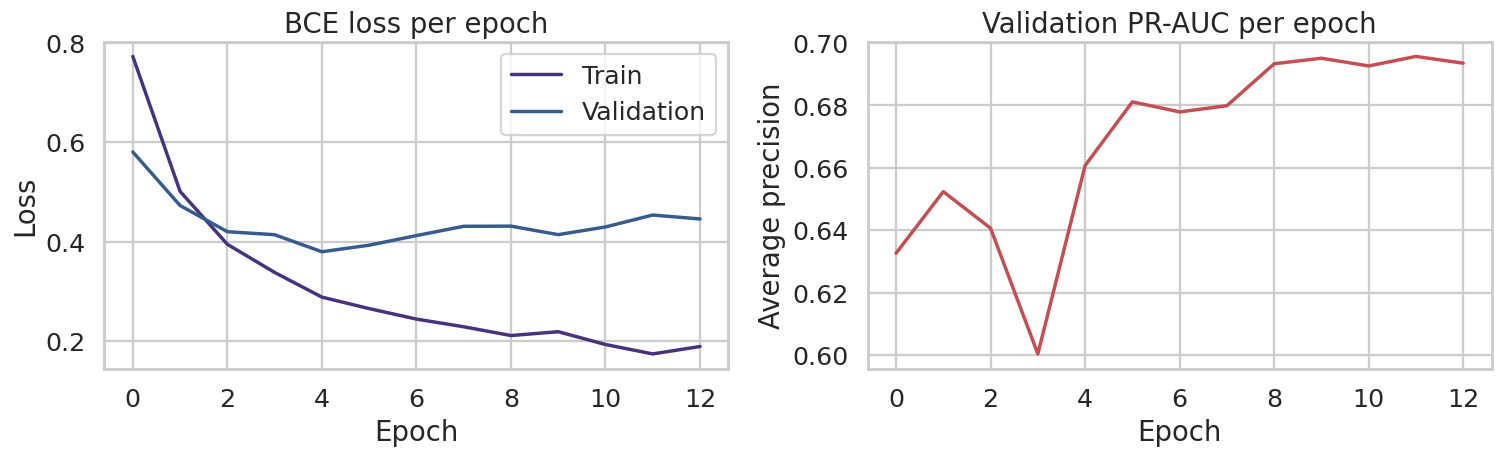

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Validation")
axes[0].set_title("BCE loss per epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["val_ap"], color="#C44E52")
axes[1].set_title("Validation PR-AUC per epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Average precision")

plt.tight_layout(); plt.show()

In [20]:
# ---- Inference on hold-out ----
net.eval()
probs_nn = []
with torch.no_grad():
    for xb, _ in test_loader:
        probs_nn.append(torch.sigmoid(net(xb.to(DEVICE))).cpu().numpy())
y_prob_nn = np.concatenate(probs_nn)
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print(classification_report(y_test, y_pred_nn,
                            target_names=["Legit", "Fraud"], digits=4))
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_nn):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_nn):.4f}")

              precision    recall  f1-score   support

       Legit     0.9999    0.9720    0.9857     56864
       Fraud     0.0535    0.9184    0.1011        98

    accuracy                         0.9719     56962
   macro avg     0.5267    0.9452    0.5434     56962
weighted avg     0.9982    0.9719    0.9842     56962

PR-AUC  : 0.7053
ROC-AUC : 0.9824


---

# 🔍 Phase 5 — Model Evaluation & Explainable AI

## 5.1 · The right metrics for fraud

| Metric | Why we care |
|--------|-------------|
| **PR-AUC (Average Precision)** | Threshold-free, ignores the huge TN class |
| **F1-score (fraud)** | Balances precision (analyst workload) and recall (missed fraud) |
| **False-Negative Rate** | Directly proportional to money lost |
| **Recall @ fixed precision** | Business SLA: e.g. "flag 80 % of fraud while keeping analyst review at 1 % of traffic" |

*Accuracy is deliberately absent — a constant predictor scores 99.83 %.*

In [21]:
def evaluate(name: str, y_true: np.ndarray, y_prob: np.ndarray,
             threshold: float = 0.5) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "PR_AUC": average_precision_score(y_true, y_prob),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "F1_fraud": f1_score(y_true, y_pred),
        "Recall_fraud": tp / max(tp + fn, 1),
        "Precision_fraud": tp / max(tp + fp, 1),
        "False_Negative_Rate": fn / max(fn + tp, 1),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


metrics_df = pd.DataFrame([
    evaluate("LightGBM", y_test, y_prob_lgb),
    evaluate("FraudNet (DL)", y_test, y_prob_nn),
]).set_index("model")

display(metrics_df.style
        .format({"PR_AUC": "{:.4f}", "ROC_AUC": "{:.4f}",
                 "F1_fraud": "{:.4f}", "Recall_fraud": "{:.4f}",
                 "Precision_fraud": "{:.4f}", "False_Negative_Rate": "{:.4f}"})
        .background_gradient(cmap="Blues", subset=["PR_AUC", "F1_fraud",
                                                    "Recall_fraud"]))

,PR_AUC,ROC_AUC,F1_fraud,Recall_fraud,Precision_fraud,False_Negative_Rate,TP,FP,FN,TN
model,,,,,,,,,,
LightGBM,0.8758,0.9780,0.8038,0.8571,0.7568,0.1429,84,27,14,56837
FraudNet (DL),0.7053,0.9824,0.1011,0.9184,0.0535,0.0816,90,1592,8,55272


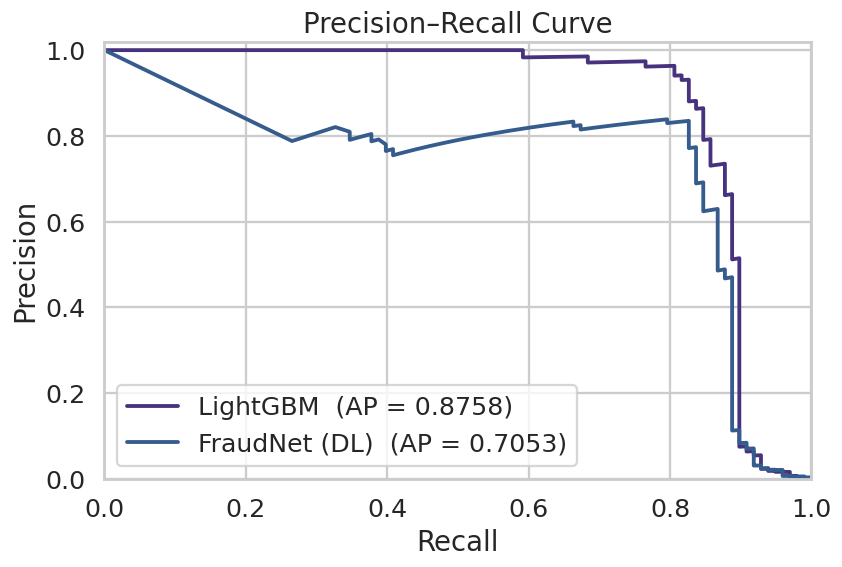

In [22]:
# Comparative PR curves
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_pr_curve(y_test, y_prob_lgb, "LightGBM", ax=ax)
plot_pr_curve(y_test, y_prob_nn,  "FraudNet (DL)", ax=ax)
plt.tight_layout(); plt.show()

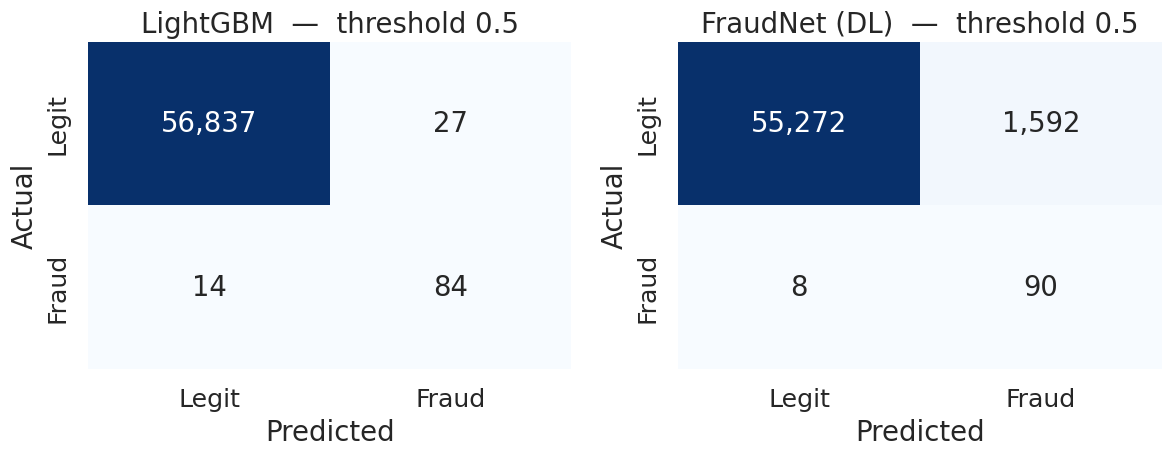

In [23]:
# Comparative confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, y_prob) in zip(axes, [("LightGBM", y_prob_lgb),
                                     ("FraudNet (DL)", y_prob_nn)]):
    cm = confusion_matrix(y_test, (y_prob >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
                xticklabels=["Legit", "Fraud"],
                yticklabels=["Legit", "Fraud"], ax=ax)
    ax.set_title(f"{name}  —  threshold 0.5")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

## 5.2 · Explainable AI with SHAP

The regulator, the fraud-ops team, and the customer whose card was blocked
all deserve an answer to *"why was this transaction flagged?"* We use
**SHAP** — Shapley additive explanations, grounded in cooperative game
theory — to attribute each prediction to individual features.

For a tree model the exact TreeSHAP algorithm runs in polynomial time, so we
can explain the entire test set at once.

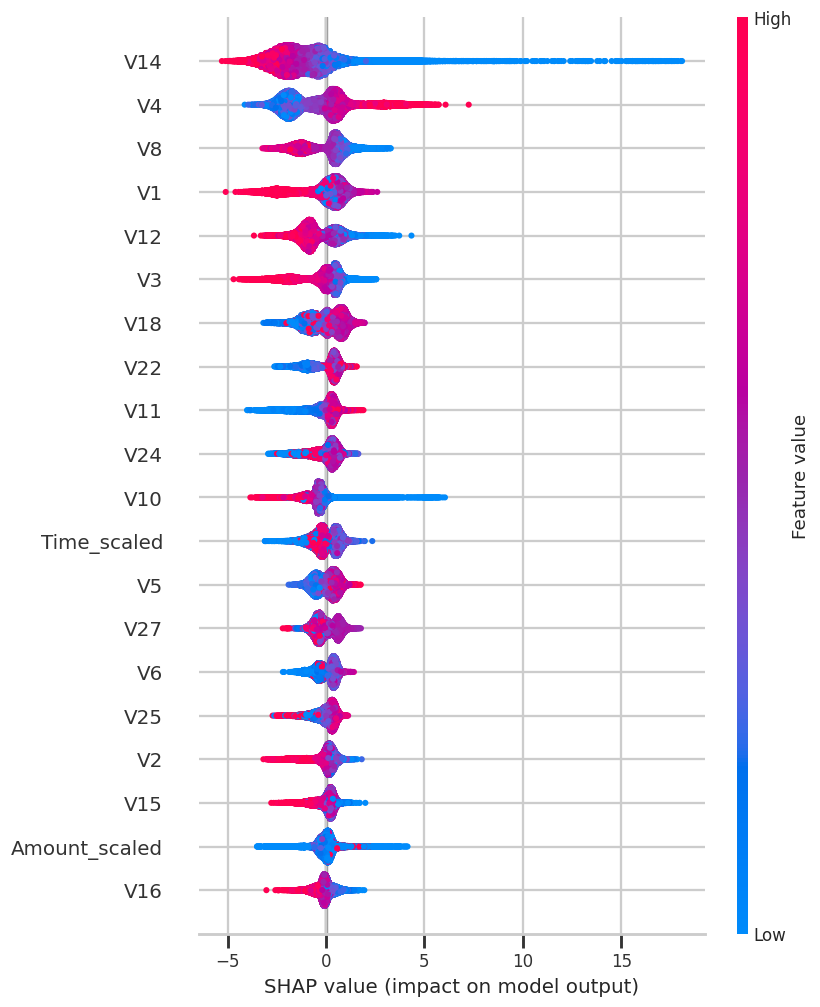

In [24]:
feature_names = ["Time_scaled", "Amount_scaled"] + [f"V{i}" for i in range(1, 29)]

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# LightGBM binary can return either a single array or [neg, pos] list
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.tight_layout(); plt.show()

### 5.3 · Local Explanation — Explain a Single Fraud

Global feature importance is useful for model documentation. But when the
ops team is looking at one transaction, they want a **local** explanation:
"which specific values pushed *this* prediction over the threshold?"

Below we pick the highest-confidence fraud prediction in the test set and
render its SHAP force plot.

Explaining test row 50636
  True label     : 1
  LGBM prob      : 1.0000


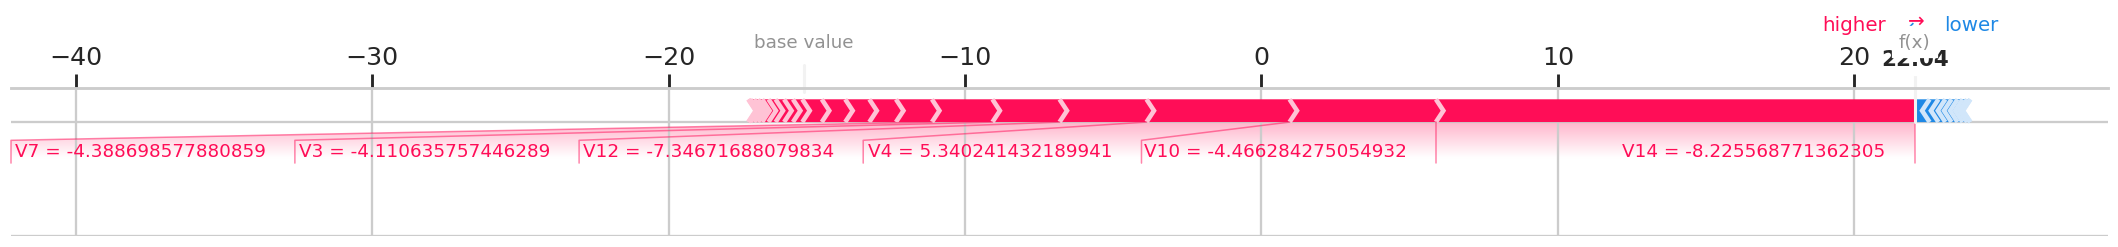

In [25]:
# Index of the highest-scoring fraud prediction
fraud_idx = np.where(y_test == 1)[0]
top_fraud_local = fraud_idx[np.argmax(y_prob_lgb[fraud_idx])]

print(f"Explaining test row {top_fraud_local}")
print(f"  True label     : {y_test[top_fraud_local]}")
print(f"  LGBM prob      : {y_prob_lgb[top_fraud_local]:.4f}")

shap.initjs()
shap.force_plot(
    explainer.expected_value if np.ndim(explainer.expected_value) == 0
        else explainer.expected_value[1],
    shap_values[top_fraud_local],
    features=X_test[top_fraud_local],
    feature_names=feature_names,
    matplotlib=True,
    show=False,
)
plt.tight_layout(); plt.show()

### 5.4 · Waterfall — the same explanation, more legible in reports

Force plots are great in dashboards; waterfalls tend to render more cleanly
in PDF reports and slides.

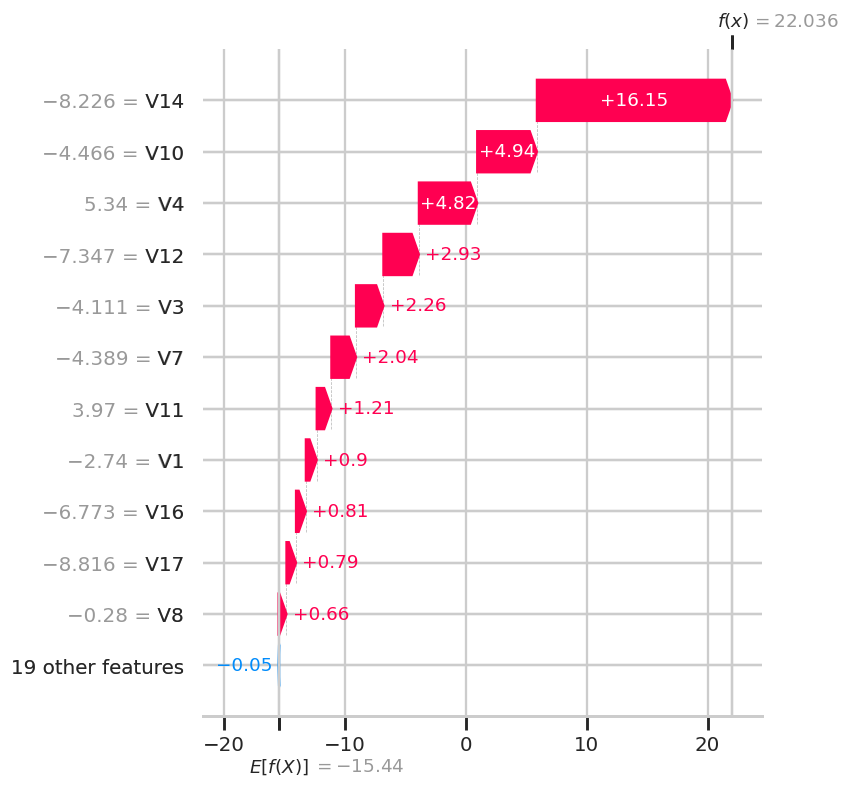

In [26]:
shap_exp = shap.Explanation(
    values=shap_values[top_fraud_local],
    base_values=(explainer.expected_value
                 if np.ndim(explainer.expected_value) == 0
                 else explainer.expected_value[1]),
    data=X_test[top_fraud_local],
    feature_names=feature_names,
)
shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.tight_layout(); plt.show()

---

# ✅ Conclusions & Next Steps

**What we built**

- A reproducible, seed-controlled pipeline that loads, scales, and splits the
  Kaggle Credit-Card Fraud dataset while respecting its heavy imbalance.
- A **LightGBM** classifier tuned with **Optuna** using SMOTE-inside-CV +
  `scale_pos_weight` to attack the imbalance from two angles.
- A **PyTorch dense network** with BatchNorm, Dropout, early stopping and LR
  scheduling — trained with `BCEWithLogitsLoss(pos_weight=…)` as a cleaner
  alternative to synthetic oversampling on the DL side.
- A rigorous evaluation framework built on the metrics that actually matter
  for fraud: **PR-AUC, F1, Recall, False-Negative Rate**.
- Global and local **SHAP** explanations so the business can trust and audit
  every decision.

**Where to take this next**

1. **Threshold optimisation** against a *cost matrix* (a false negative costs
   the average transaction value; a false positive costs an analyst-minute).
2. **Stacking** — LightGBM probabilities as an input feature to a shallow
   neural net, or vice versa.
3. **Real-time serving** — export the LightGBM model to `treelite` for sub-ms
   inference and wrap the DL model in `torch.jit.trace`.
4. **Drift monitoring** — set up Population Stability Index (PSI) alerts on
   the top-10 SHAP features; a drift there is your earliest warning that
   attackers are adapting.
5. **Bring in the IEEE-CIS dataset** — richer categorical/identity features
   let you demonstrate `CatBoost` and target encoding on top of what we did
   here.

---

*Notebook authored end-to-end; run top-to-bottom for a reproducible portfolio
artefact.*